# HillClimbing


Created on Thu Nov 27 15:59:22 2025
Changed on Thu Dec 04 12:31:40 2025 -- Add Ackley Problem

@author: gustaaragao

## Objetivo
Aplicar e explorar o **Hill Climbing** em dois problemas:
- **Sphere** (convexo, ótimo global em $x=0$)
- **Ackley** (multimodal, muitos ótimos locais)

O experimento varre hiperparâmetros do HC:
- `p`: probabilidade de perturbar cada variável por iteração
- `r`: amplitude do ruído uniforme (passo)

Critério de parada: `max_evaluations = 50.000` avaliações da função objetivo.

## Sphere Problem

### f(x) = $\Sigma$ x²

- Local optimum = Global optimum -> x* = [0]

In [2]:
from src.problems.Sphere import Sphere
from src.problems.Ackley import Ackley
from src.MOEAs.HillClimbing import HillClimbing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Parameters for Hill-Climbing experiments
D = 30                                              # Number of Decision Variables (dimensionality)
max_evaluations = 50_000                            # Maximum number of function evaluations

# Probability values: controls how many variables are perturbed in each iteration
# Lower values --> fewer variables changed --> more local exploration
# Higher values --> more variables changed --> broader exploration
p_values = [0.125, 0.25, 0.5, 1.0]

# Range values: controls the magnitude of perturbation noise
# Lower values --> small steps --> slow convergence, fine-tuning
# Higher values --> large steps --> faster convergence, risk of overshooting
r_values = [0.5, 1.0, 5.0, 10.0, 20.0, 50.0]

In [4]:
def simulate_sphere(p, r):
   # Create the problem
    problem = Sphere(numberOfDecisionVariables=D)
    
    # Create the algorithm
    algorithm = HillClimbing(
        problem=problem,
        maxEvaluations=max_evaluations,
        probability=p,
        range_noise=r
    )
    
    # Execute the algorithm
    best = algorithm.execute()
    
    result = {
        'p': p,
        'r': r,
        'best_fitness': best.objectives[0],
        'evaluations': algorithm.evaluations
    }
    
    return result


In [5]:
rows_sphere = []

# Simulate Hill-Climbing on Sphere Problem
for p in p_values:
    for r in r_values:
        rows_sphere.append(simulate_sphere(p, r))

df_sphere = pd.DataFrame(rows_sphere)
df_sphere

,p,r,best_fitness,evaluations
0,0.125,0.5,0.000754,50000
1,0.125,1.0,0.002098,50000
2,0.125,5.0,0.067409,50000
3,0.125,10.0,0.247832,50000
4,0.125,20.0,0.990102,50000
5,0.125,50.0,3.082117,50000
6,0.250,0.5,0.039227,50000
7,0.250,1.0,0.122602,50000
8,0.250,5.0,3.342034,50000
9,0.250,10.0,8.564757,50000


## Resultados (Sphere): Heatmap p × r
O heatmap abaixo resume o resultado final (`best_fitness`) do Hill Climbing para cada combinação de parâmetros $(p, r)$.
- **Quanto menor o valor, melhor** (problema de minimização).
- A célula com menor valor indica a **melhor configuração observada**.

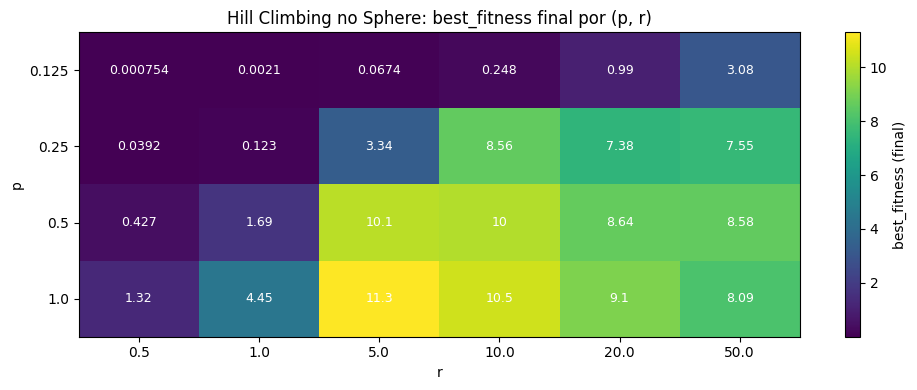

Melhor configuração (Sphere):
p                   0.125000
r                   0.500000
best_fitness        0.000754
evaluations     50000.000000
Name: 0, dtype: float64


In [6]:
# Heatmap (matplotlib) do best_fitness por (p, r)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_heatmap_pr(df, title):
    required = {"p", "r", "best_fitness"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"DataFrame sem colunas necessárias: {sorted(missing)}")

    pivot = df.pivot(index="p", columns="r", values="best_fitness").sort_index().sort_index(axis=1)
    values = pivot.to_numpy(dtype=float)
    p_index = pivot.index.to_numpy()
    r_cols = pivot.columns.to_numpy()

    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(values, aspect="auto", cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("r")
    ax.set_ylabel("p")
    ax.set_xticks(np.arange(len(r_cols)))
    ax.set_yticks(np.arange(len(p_index)))
    ax.set_xticklabels(r_cols)
    ax.set_yticklabels(p_index)

    # Anotações (valores nas células)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            v = values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.3g}", ha="center", va="center", color="white", fontsize=9)

    fig.colorbar(im, ax=ax, label="best_fitness (final)")
    plt.tight_layout()
    plt.show()

plot_heatmap_pr(df_sphere, "Hill Climbing no Sphere: best_fitness final por (p, r)")

# Melhor configuração observada
best_row = df_sphere.loc[df_sphere["best_fitness"].astype(float).idxmin()]
print("Melhor configuração (Sphere):")
print(best_row)

# Graphs of the Function from the “Sphere” Problem

In [ ]:
# Create a 2D grid for visualization
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)

# Calculate Sphere function values (for 2D: f(x,y) = x² + y²)
Z = X**2 + Y**2

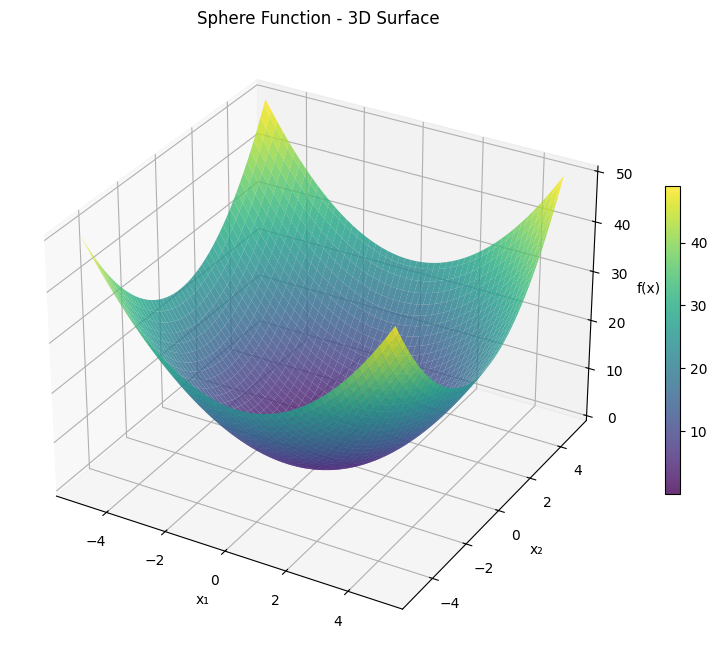

In [ ]:
# 3D Surface plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_zlabel('f(x)')
ax.set_title('Sphere Function - 3D Surface')
fig.colorbar(surf, ax=ax, shrink=0.5)
plt.show()

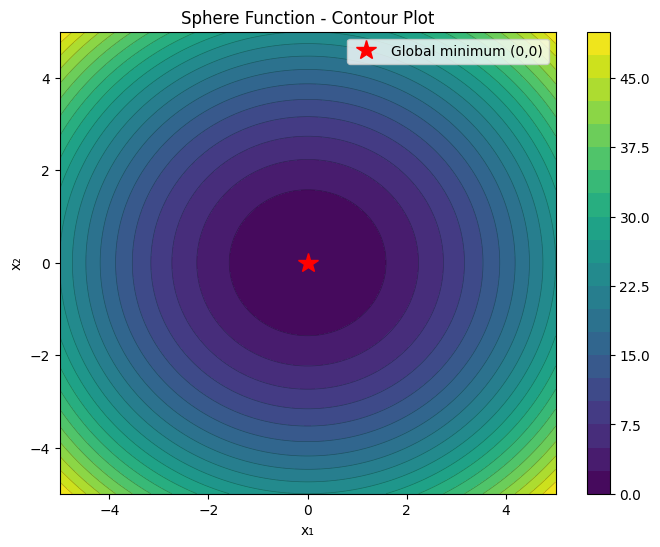

In [ ]:
# Contour plot
fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(X, Y, Z, levels=20, cmap='viridis')
ax.contour(X, Y, Z, levels=20, colors='black', alpha=0.3, linewidths=0.5)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title('Sphere Function - Contour Plot')
ax.plot(0, 0, 'r*', markersize=15, label='Global minimum (0,0)')
ax.legend()
fig.colorbar(contour, ax=ax)
plt.show()

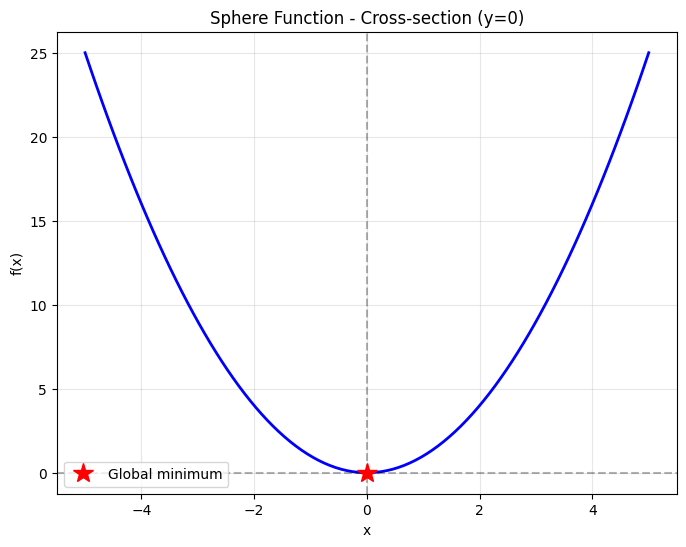

In [ ]:
# Cross-section (1D slice at y=0)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, x**2, 'b-', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Sphere Function - Cross-section (y=0)')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax.plot(0, 0, 'r*', markersize=15, label='Global minimum')
ax.legend()
plt.show()

## Ackley Problem

A função de Ackley (para $D$ variáveis) pode ser escrita como:

$$
f(x) = -a\,\exp\left(-b\,\sqrt{\frac{1}{D}\sum_{i=1}^D x_i^2}\right) - \exp\left(\frac{1}{D}\sum_{i=1}^D \cos(c\,x_i)\right) + a + e
$$

- Global minimum: $x^* = [0,\dots,0]$
- Local minima: a função tem muitos mínimos locais

In [ ]:
# Parameters
a = 20
b = 0.2
c = 2*np.pi

In [ ]:
def simulate_ackley(p, r):
   # Create the problem
    problem = Ackley(numberOfDecisionVariables=D, a=a, b=b, c=c)
    
    # Create the algorithm
    algorithm = HillClimbing(
        problem=problem,
        maxEvaluations=max_evaluations,
        probability=p,
        range_noise=r
    )
    
    # Execute the algorithm
    best = algorithm.execute()
    
    result = {
        'p': p,
        'r': r,
        'best_fitness': best.objectives[0],
        'evaluations': algorithm.evaluations
    }
    
    return result

In [ ]:
rows_ackley = []

# Simulate Hill-Climbing on Ackley Problem
for p in p_values:
    for r in r_values:
        rows_ackley.append(simulate_ackley(p, r))

df_ackley = pd.DataFrame(rows_ackley)
df_ackley

,p,r,best_fitness,evaluations
0,0.125,0.5,0.023200,50000
1,0.125,1.0,0.033015,50000
2,0.125,5.0,0.355972,50000
3,0.125,10.0,0.516445,50000
4,0.125,20.0,1.513492,50000
5,0.125,50.0,2.503472,50000
6,0.250,0.5,0.233410,50000
7,0.250,1.0,0.564901,50000
8,0.250,5.0,2.819441,50000
9,0.250,10.0,3.424604,50000


## Resultados (Ackley): Heatmap p × r
No Ackley (multimodal), o heatmap ajuda a ver rapidamente quais combinações $(p, r)$ foram mais eficazes em evitar estagnação em mínimos locais.
- **Quanto menor o valor, melhor**.
- Em geral, espera-se maior variabilidade do que no Sphere.

In [ ]:
plot_heatmap_pr(df_ackley, "Hill Climbing no Ackley: best_fitness final por (p, r)")

best_row_ackley = df_ackley.loc[df_ackley["best_fitness"].astype(float).idxmin()]
print("Melhor configuração (Ackley):")
print(best_row_ackley)

## Texto para relatório (interpretação dos heatmaps e bons resultados)
Os heatmaps de **Sphere** e **Ackley** apresentam, para cada par de parâmetros $(p, r)$, o valor final de `best_fitness` obtido ao término das `max_evaluations` avaliações. Como ambos os problemas são de **minimização**, células com valores menores representam **melhor desempenho**.

### Sphere
No problema Sphere (convexo, mínimo global em $x^*=(0,\dots,0)$), espera-se que um método de busca local como Hill Climbing obtenha valores muito baixos de `best_fitness` quando os parâmetros permitem um equilíbrio entre **passos suficientemente grandes para progredir** e **passos suficientemente pequenos para refinar** próximo ao ótimo. O heatmap evidencia uma região de parâmetros com melhor desempenho: as menores células representam configurações em que o algoritmo convergiu mais próximo do mínimo global.

No notebook, a melhor configuração observada é impressa em `best_row` logo abaixo do heatmap. Essa linha pode ser reportada no texto como, por exemplo: “a melhor configuração foi $(p, r)=(\dots)$, obtendo `best_fitness=...` ao final de 50.000 avaliações”.

> Interpretação típica: valores muito altos de `r` podem gerar perturbações grandes demais e dificultar o refinamento; valores muito baixos podem tornar a convergência lenta. Já `p` controla quantas variáveis são perturbadas por iteração: `p` pequeno favorece exploração local em poucas dimensões, enquanto `p` grande altera muitas dimensões ao mesmo tempo, podendo prejudicar o ajuste fino no final.

### Ackley
No Ackley (multimodal, muitos mínimos locais), o Hill Climbing tende a apresentar maior risco de **estagnação**. Por isso, os valores do heatmap frequentemente mostram mais variação e, dependendo de $(p, r)$, resultados finais mais distantes do mínimo global. Ainda assim, o heatmap permite identificar as combinações que apresentaram os melhores resultados observados (menores células).

Assim como no Sphere, a melhor configuração observada no Ackley é impressa em `best_row_ackley`. No relatório, é relevante destacar que, mesmo na melhor configuração, a multimodalidade do Ackley pode limitar um método estritamente local, o que motiva o uso de algoritmos populacionais (por exemplo, Algoritmo Genético) para aumentar exploração do espaço de busca.

### Observação sobre robustez
Se você rodou **apenas 1 execução por configuração**, os heatmaps refletem uma amostra única. Para fortalecer a análise, recomenda-se repetir cada configuração com múltiplas seeds (por exemplo, 20) e então usar no heatmap a **média** (e complementar com boxplots) para quantificar a variabilidade do método.

# Graphs of the Function from the "Ackley" Problem

In [ ]:
# Create a 2D grid for Ackley visualization (2D slice)
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)

# For the 2D case, D=2 => 1/D = 0.5
Z = -a * np.exp(-b * np.sqrt(0.5 * (X**2 + Y**2))) - np.exp(
    0.5 * (np.cos(c * X) + np.cos(c * Y))
 ) + a + np.e

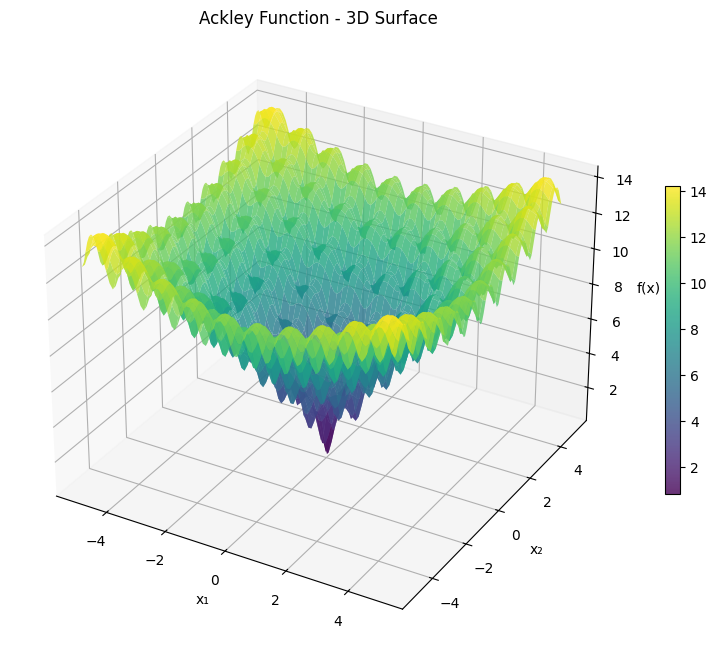

In [ ]:
# 3D Surface plot - Ackley
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_zlabel('f(x)')
ax.set_title('Ackley Function - 3D Surface')
fig.colorbar(surf, ax=ax, shrink=0.5)
plt.show()

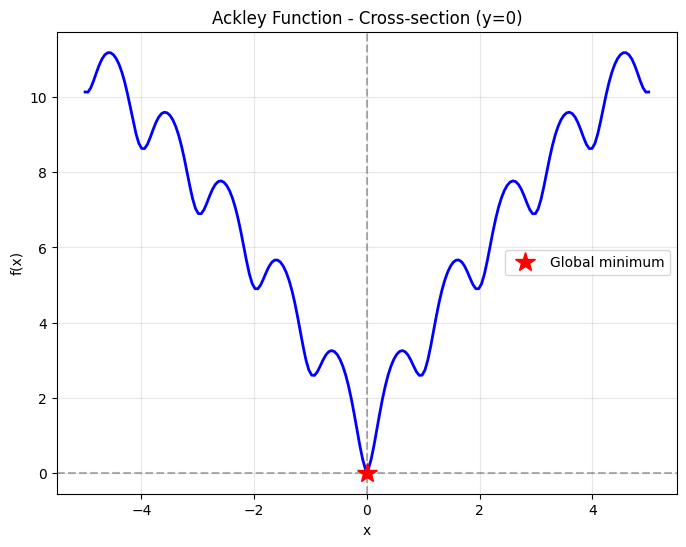

In [ ]:
# Cross-section (1D slice at y=0) - Ackley
x_1d = np.linspace(-5, 5, 200)

# For y=0 in 2D: cos(c*y)=cos(0)=1
z_1d = (
    -a * np.exp(-b * np.sqrt(0.5 * x_1d**2))
    - np.exp(0.5 * (np.cos(c * x_1d) + 1))
    + a
    + np.e
 )

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x_1d, z_1d, 'b-', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Ackley Function - Cross-section (y=0)')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax.plot(0, 0, 'r*', markersize=15, label='Global minimum')
ax.legend()
plt.show()